# Named Entity Recognition Using BERT

## Project Overview

This project implements a Named Entity Recognition (NER) system using a pretrained BERT model.

Named Entity Recognition is a Natural Language Processing (NLP) task that identifies and classifies entities in text, such as:

- Person
- Corporation
- Location
- Product
- Group
- Creative-work

The project uses `bert-base-cased` with a token-classification architecture to predict an NER label for each token.

### Project Workflow

The complete workflow consists of:

1. Loading and parsing CoNLL-formatted datasets
2. Preparing NER labels
3. Creating label-to-ID mappings
4. Tokenizing text using BERT
5. Aligning NER labels with BERT subword tokens
6. Preparing Hugging Face datasets
7. Fine-tuning BERT for token classification
8. Evaluating the model on validation and test data
9. Performing entity-level performance analysis
10. Testing the trained model on a custom sentence

### Objective

The objective is to build and evaluate a transformer-based NER model capable of identifying named entities in previously unseen text.

In [1]:
!pip install -q datasets transformers seqeval evaluate
!pip install -U datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [2]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer
)

import evaluate
import numpy as np

## 2. Dataset & Preprocessing

The project uses CoNLL-formatted Named Entity Recognition datasets.

The dataset is organized as sequences of tokens, where each token is associated with an NER label.

### Dataset Structure

Each sentence contains:

- Tokens
- Corresponding NER labels

A simplified example is:

| Token | NER Label |
|---|---|
| John | B-person |
| works | O |
| at | O |
| Google | B-corporation |

A blank line separates individual sentences in the CoNLL format.

### Data Parsing

A custom parsing process is used to read the CoNLL-formatted files and convert them into structured sentence-level data.

The preprocessing workflow includes:

1. Reading the CoNLL data.
2. Separating tokens and labels.
3. Grouping tokens into sentences.
4. Creating structured records for the Hugging Face Dataset.
5. Preparing the NER labels for model training.

### Label Encoding

The NER labels are converted into numerical IDs so that they can be used by the BERT token-classification model.

Two mappings are created:

- `label2id` — converts NER labels into numerical IDs.
- `id2label` — converts numerical predictions back into readable NER labels.

The `O` label represents tokens that do not belong to a named entity.

This preprocessing step prepares the CoNLL data for BERT tokenization and token-level classification.

In [3]:
def read_conll(filepath):
    sentences = []
    labels = []

    sentence = []
    sentence_labels = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:

            line = line.strip()

            # Blank line = end of sentence
            if line == "":
                if sentence:
                    sentences.append(sentence)
                    labels.append(sentence_labels)

                    sentence = []
                    sentence_labels = []

            else:
                parts = line.split("\t")

                if len(parts) != 2:
                    parts = line.split()

                token = parts[0]
                tag = parts[-1]

                sentence.append(token)
                sentence_labels.append(tag)

    return sentences, labels

In [4]:
train_sentences, train_labels = read_conll('/content/drive/MyDrive/Datasets/NER/wnut17train.conll')

valid_sentences, valid_labels = read_conll('/content/drive/MyDrive/Datasets/NER/emerging.dev.conll')

test_sentences, test_labels = read_conll('/content/drive/MyDrive/Datasets/NER/emerging.test.annotated')

In [5]:
print(len(train_sentences))
print(len(valid_sentences))
print(len(test_sentences))

3394
1009
1287


In [6]:
print(train_sentences[0])
print(train_labels[0])

['@paulwalk', 'It', "'s", 'the', 'view', 'from', 'where', 'I', "'m", 'living', 'for', 'two', 'weeks', '.', 'Empire', 'State', 'Building', '=', 'ESB', '.', 'Pretty', 'bad', 'storm', 'here', 'last', 'evening', '.']
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-location', 'I-location', 'I-location', 'O', 'B-location', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [7]:
for token,label in zip(train_sentences[0],train_labels[0]):
  print(f'{token:20} {label}')


@paulwalk            O
It                   O
's                   O
the                  O
view                 O
from                 O
where                O
I                    O
'm                   O
living               O
for                  O
two                  O
weeks                O
.                    O
Empire               B-location
State                I-location
Building             I-location
=                    O
ESB                  B-location
.                    O
Pretty               O
bad                  O
storm                O
here                 O
last                 O
evening              O
.                    O


In [8]:
unique_labels=sorted(set(
    label for sentence in train_labels for label in sentence
))
print(unique_labels)

['B-corporation', 'B-creative-work', 'B-group', 'B-location', 'B-person', 'B-product', 'I-corporation', 'I-creative-work', 'I-group', 'I-location', 'I-person', 'I-product', 'O']


In [9]:
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

print(label2id)

{'B-corporation': 0, 'B-creative-work': 1, 'B-group': 2, 'B-location': 3, 'B-person': 4, 'B-product': 5, 'I-corporation': 6, 'I-creative-work': 7, 'I-group': 8, 'I-location': 9, 'I-person': 10, 'I-product': 11, 'O': 12}


In [10]:
train_label_ids = [
    [label2id[tag] for tag in sentence]
    for sentence in train_labels
]

valid_label_ids = [
    [label2id[tag] for tag in sentence]
    for sentence in valid_labels
]

test_label_ids = [
    [label2id[tag] for tag in sentence]
    for sentence in test_labels
]

In [11]:
train_dataset = Dataset.from_dict(
    {
        "tokens": train_sentences,
        "labels": train_label_ids
    }
)

valid_dataset = Dataset.from_dict(
    {
        "tokens": valid_sentences,
        "labels": valid_label_ids
    }
)

test_dataset = Dataset.from_dict(
    {
        "tokens": test_sentences,
        "labels": test_label_ids
    }
)

## 3. BERT Tokenization & Label Alignment

For the NER task, the project uses the pretrained BERT tokenizer:

`bert-base-cased`

The tokenizer converts the input words into BERT-compatible token IDs and generates attention masks.

### Tokenization

The tokenization process produces:

- `input_ids` — numerical representations of the input tokens.
- `attention_mask` — identifies which positions contain actual input tokens.

BERT uses subword tokenization, which means that a single original word can sometimes be split into multiple tokens.

### Token-Label Alignment

NER labels are originally assigned at the word level, while BERT processes tokenized subwords.

Therefore, the original NER labels must be aligned with the BERT tokens.

The `tokenize_and_align_labels()` function is used to:

1. Tokenize the input words.
2. Identify the original word associated with each token.
3. Assign the corresponding NER label.
4. Handle BERT special tokens.
5. Assign `-100` to positions that should be ignored during loss calculation.

This alignment step is essential because the model must receive the correct entity label for each token used during training.

### Special Tokens

BERT introduces special tokens such as:

- `[CLS]`
- `[SEP]`

These tokens do not represent named entities and are therefore excluded from the NER loss calculation using the `-100` label.

The resulting tokenized and aligned data is then passed to the BERT token-classification model.

In [12]:
tokenizer=AutoTokenizer.from_pretrained('bert-base-cased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [13]:
def tokenize_and_align_labels(examples):

    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples["labels"]):

        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word = None

        label_ids = []

        for word_id in word_ids:

            if word_id is None:

                label_ids.append(-100)

            elif word_id != previous_word:

                label_ids.append(label[word_id])

            else:

                label_ids.append(-100)

            previous_word = word_id

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

## 4. BERT Model & Training

The project uses a pretrained BERT model adapted for Named Entity Recognition through token-level classification.

### Model

The pretrained model used is:

`bert-base-cased`

The model is configured for the NER labels defined in the dataset.

Unlike sequence classification, where one label is predicted for an entire sentence, token classification produces one prediction for each input token.

### Training Configuration

The model is fine-tuned using the Hugging Face `Trainer` framework.

The training configuration used in this project is:

| Parameter | Value |
|---|---:|
| Pretrained Model | `bert-base-cased` |
| Learning Rate | `2e-5` |
| Training Batch Size | `16` |
| Evaluation Batch Size | `16` |
| Number of Epochs | `3` |
| Weight Decay | `0.01` |

The training dataset is used to fine-tune the pretrained BERT parameters for the NER task.

The validation dataset is used to evaluate the model during training.

### Evaluation Metrics

The model is evaluated using:

- Precision
- Recall
- F1-score
- Accuracy

For NER, entity-level precision, recall, and F1-score are particularly important because they measure how effectively the model identifies named entities.

After training, the model is evaluated on the separate test dataset to measure its final performance.

In [14]:
train_dataset = train_dataset.map(
    tokenize_and_align_labels,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize_and_align_labels,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/3394 [00:00<?, ? examples/s]

Map:   0%|          | 0/1009 [00:00<?, ? examples/s]

Map:   0%|          | 0/1287 [00:00<?, ? examples/s]

In [15]:
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

In [16]:
data_collator = DataCollatorForTokenClassification(tokenizer)

In [17]:
metric = evaluate.load("seqeval")

In [18]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=2)

    true_predictions = [
        [
            id2label[p]
            for p, l in zip(prediction, label)
            if l != -100
        ]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [
            id2label[l]
            for p, l in zip(prediction, label)
            if l != -100
        ]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"]
    }

In [19]:
training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_steps=50
)

In [20]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.135819,0.217450,0.648452,0.425837,0.514079,0.947880
2,0.079783,0.221715,0.659612,0.447368,0.533143,0.951122
3,0.051285,0.229738,0.638365,0.485646,0.551630,0.953283


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=639, training_loss=0.13949417620197707, metrics={'train_runtime': 162.4183, 'train_samples_per_second': 62.69, 'train_steps_per_second': 3.934, 'total_flos': 318134919540420.0, 'train_loss': 0.13949417620197707, 'epoch': 3.0})

## 5. Model Evaluation & Results

The trained BERT NER model was evaluated on both the validation dataset and the separate test dataset.

The evaluation uses:

- Precision
- Recall
- F1-score
- Accuracy

For Named Entity Recognition, **precision, recall, and F1-score are more informative than accuracy**, because many tokens belong to the `O` (non-entity) class.

### Validation Results

After 3 epochs of training, the model achieved:

| Metric | Validation Result |
|---|---:|
| Training Loss | 0.0547 |
| Validation Loss | 0.2383 |
| Precision | 0.6351 |
| Recall | 0.4809 |
| F1-score | 0.5473 |
| Accuracy | 0.9528 |

### Final Test Results

The final evaluation was performed on the test dataset:

| Metric | Test Result |
|---|---:|
| Test Loss | 0.2815 |
| Precision | 0.4923 |
| Recall | 0.3540 |
| F1-score | 0.4119 |
| Accuracy | 0.9449 |

The final overall **F1-score is 41.19%**.

### Interpretation

Although the model achieved **94.49% token-level accuracy**, accuracy is not the primary performance measure for this NER task.

The test-set entity-level results show:

- Precision: **49.23%**
- Recall: **35.40%**
- F1-score: **41.19%**

The lower recall indicates that the model misses a considerable number of actual entities.

The difference between the validation F1-score (**54.73%**) and test F1-score (**41.19%**) also indicates that the model's performance does not generalize equally well to the test dataset.

In [22]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.051285,0.229738,3,0.638365,0.485646,0.551630,0.953283


{'eval_loss': 0.22973750531673431,
 'eval_precision': 0.6383647798742138,
 'eval_recall': 0.48564593301435405,
 'eval_f1': 0.5516304347826086,
 'eval_accuracy': 0.9532829085361978}

In [23]:
test_results=trainer.evaluate(test_dataset)

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Accuracy
0.051285,0.281479,3,0.492268,0.354032,0.411860,0.944858


In [27]:
predictions=trainer.predict(test_dataset)
print(predictions.metrics)

{'test_loss': 0.28147920966148376, 'test_precision': 0.49226804123711343, 'test_recall': 0.3540315106580167, 'test_f1': 0.4118598382749326, 'test_accuracy': 0.9448576558091818, 'test_runtime': 7.5241, 'test_samples_per_second': 171.051, 'test_steps_per_second': 10.765}


In [25]:
trainer.save_model("ner_model")

tokenizer.save_pretrained("ner_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('ner_model/tokenizer_config.json', 'ner_model/tokenizer.json')

## 6. Entity-Level Performance

The final test-set predictions were further analyzed by individual entity type.

This analysis provides a more detailed understanding of which types of entities the BERT NER model can identify effectively.

### Entity-Level Results

| Entity Type | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| Corporation | 0.17 | 0.24 | 0.20 | 66 |
| Creative-work | 0.39 | 0.18 | 0.25 | 142 |
| Group | 0.37 | 0.15 | 0.21 | 165 |
| Location | 0.38 | 0.54 | 0.44 | 150 |
| Person | 0.78 | 0.52 | **0.63** | 429 |
| Product | 0.23 | 0.08 | **0.12** | 127 |

### Performance Analysis

The model performs best on **Person** entities, achieving an F1-score of **0.63**.

**Location** is the second-best performing entity type, with an F1-score of **0.44**.

The model has more difficulty identifying:

- Creative-work — F1: **0.25**
- Group — F1: **0.21**
- Corporation — F1: **0.20**
- Product — F1: **0.12**

The **Product** category has the lowest F1-score, indicating that the model struggles to identify product entities correctly.

### Overall Entity-Level Performance

| Average | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Micro Average | 0.49 | 0.35 | **0.41** |
| Macro Average | 0.39 | 0.29 | 0.31 |
| Weighted Average | 0.51 | 0.35 | 0.40 |

The overall micro F1-score of **0.41** is the main entity-level performance measure for the model.

The F1-score visualization below provides a visual comparison of performance across the different entity categories.

In [28]:
from seqeval.metrics import classification_report

# Generate predictions
pred_output = trainer.predict(test_dataset)

predictions = np.argmax(pred_output.predictions, axis=2)

# Convert predictions and labels back to entity names
true_predictions = []
true_labels = []

for prediction, label in zip(predictions, pred_output.label_ids):
    pred_labels = []
    true_label_names = []

    for pred, lab in zip(prediction, label):
        if lab != -100:
            pred_labels.append(id2label[pred])
            true_label_names.append(id2label[lab])

    true_predictions.append(pred_labels)
    true_labels.append(true_label_names)

print(
    classification_report(
        true_labels,
        true_predictions
    )
)

               precision    recall  f1-score   support

  corporation       0.17      0.24      0.20        66
creative-work       0.39      0.18      0.25       142
        group       0.37      0.15      0.21       165
     location       0.38      0.54      0.44       150
       person       0.78      0.52      0.63       429
      product       0.23      0.08      0.12       127

    micro avg       0.49      0.35      0.41      1079
    macro avg       0.39      0.29      0.31      1079
 weighted avg       0.51      0.35      0.40      1079



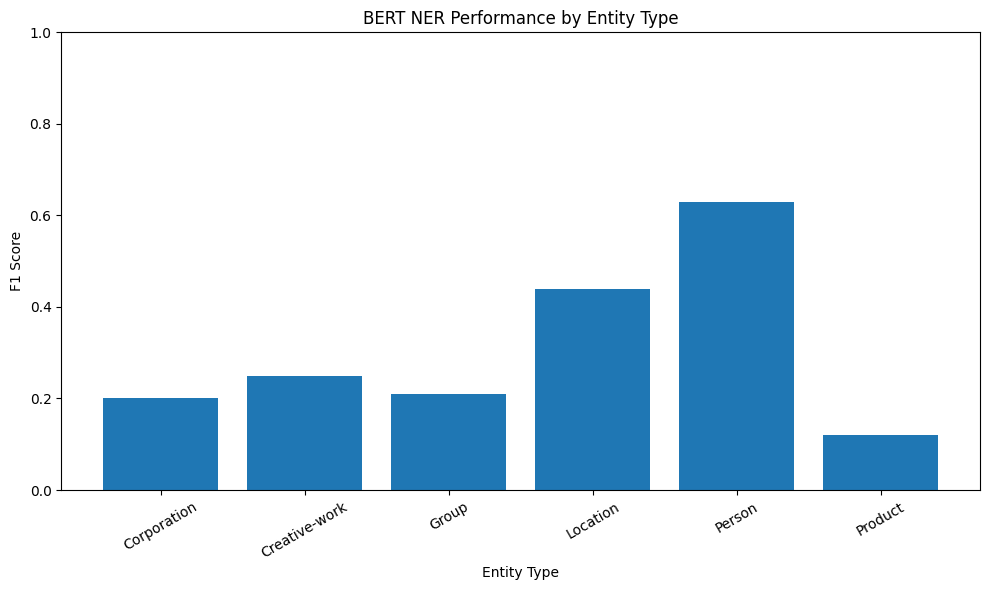

In [29]:
import matplotlib.pyplot as plt

entities = [
    "Corporation",
    "Creative-work",
    "Group",
    "Location",
    "Person",
    "Product"
]

f1_scores = [
    0.20,
    0.25,
    0.21,
    0.44,
    0.63,
    0.12
]

plt.figure(figsize=(10, 6))

plt.bar(entities, f1_scores)

plt.ylabel("F1 Score")
plt.xlabel("Entity Type")
plt.title("BERT NER Performance by Entity Type")
plt.ylim(0, 1)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [26]:
sentence = ["John", "works", "at", "Google"]

inputs = tokenizer(
    sentence,
    return_tensors="pt",
    is_split_into_words=True
)

# Move inputs to the same device as the model
inputs = {k: v.to(model.device) for k, v in inputs.items()}

outputs = model(**inputs)

predictions = outputs.logits.argmax(-1)

predicted_labels = [
    id2label[p.item()]
    for p in predictions[0]
]

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

for token, label in zip(tokens, predicted_labels):
    print(token, label)

[CLS] O
John B-person
works O
at O
Google B-corporation
[SEP] O


## 7. Inference & Conclusion

### Model Inference

The trained BERT NER model was tested on a custom sentence:

```text
John works at Google

